# Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Setting Up the Battery and Market Configuration

In [2]:
battery_config = {
    'energy': 1,
    'power': 1,
    'cycle_limit': 2,
    'service_life': 10, 
    'efficiency': 0.95, 
    'maxSOC': 1, 
    'minSOC': 0, 
    'startSOC': 0.5,
    'DoD': 1, 
    'costs': 250  # costs in €/kWh
}

market_config = {
    'DA': {'t_delivery': 1, 'power_share': 0.5, 'capture_rate': 0.9, 'capacity_share': 0.2},
    'IDA1': {'t_delivery': 0.25, 'power_share': 0.5, 'capture_rate': 0.9, 'capacity_share': 1},
    'ID1': {'t_delivery': 0.25, 'power_share': 0.5, 'capture_rate': 0.9, 'capacity_share': 0.5},
    'FCR': {'t_delivery': 4, 'power_share': 0.8, 'capture_rate': 6/6, 'capacity_share': 1},
    'aFRR Capacity': {'t_delivery': 4, 'power_share': 0.5, 'capture_rate': 6/6, 'capacity_share': 1},
    'FinancialTrading': { 't_delivery': 0.25, 'power_share': 0.5,'capture_rate': 0.1, 'capacity_share': 1}
 }

# calculate additional battery parameters. Aging costs are based on initial invest
aging_costs = battery_config['costs'] * 1000 / (battery_config['service_life'] * battery_config['cycle_limit'] * 365)  # in €/MWh
battery_config['aging_costs'] = aging_costs

# Specifying the Date and the Market

In [3]:
day = '2024-09-30'

In [4]:
raw_data_path = 'marketdata'

results_df_day = pd.DataFrame()
timestamp_of_15min = pd.date_range(start=day + ' 00:00', periods=96, freq='15min')
results_df_day = pd.DataFrame(columns=['DA', 'ID1', 'aFRR Capacity', 'Financial', 'SOC'], index=timestamp_of_15min)

#turn index in ttz aware for europe
results_df_day.index = results_df_day.index.tz_localize('Europe/Berlin')

# 1) aFRR Capacity Revenues

In [5]:
market_path = 'aFRR_capacity_data'
folder_path = os.path.join('..',raw_data_path, market_path)
file_name = f'afrr_capacity_{day}.xlsx'
path = os.path.join(folder_path, file_name)

# PRICES
all_afrr_data = pd.read_excel(path, header=0, index_col=0)  # index is date
afrr_prices_ger = all_afrr_data['GERMANY_AVERAGE_CAPACITY_PRICE_[(EUR/MW)/h]']
afrr_prices_ger.index = pd.to_datetime(afrr_prices_ger.index)

# SET MARKETABLE POWER
afrr_power_symmetric = min(battery_config['energy'] / 2, battery_config['power'])  # for symmetric aFRR bids
afrr_power_share = afrr_power_symmetric * market_config['aFRR Capacity']['power_share']  # share of the battery power that is used for aFRR
market_config['aFRR Capacity']['marketable_power'] = afrr_power_share

# ADJUST SOC
energy_afrr = market_config['aFRR Capacity']['marketable_power'] * 1   # we have to reserve 1 hour
#max_soc_after_afrr = (battery_config['energy'] - energy_afrr)/ battery_config['energy']
#min_soc_after_afrr = energy_afrr/ battery_config['energy']

battery_config['maxSOC'] = battery_config['maxSOC'] - energy_afrr / battery_config['energy']
battery_config['minSOC'] = battery_config['minSOC'] + energy_afrr / battery_config['energy']

# REVENUE
afrr_revenue_per_hour = afrr_prices_ger * market_config['aFRR Capacity']['marketable_power']  # in € per hour

afrr_revenue = afrr_revenue_per_hour * market_config['aFRR Capacity']['t_delivery']  # scale up to 4 hour blocks

# add the first and the 7th, the second and the 8th and so on
block_revenues_afrr = pd.Series(index=range(6), data=0.0)
for i in range(6):
    block_revenues_afrr[i] = afrr_revenue[i] + afrr_revenue[i + 6]




C:\ProgramData\Anaconda3\lib\site-packages\openpyxl\styles\stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


# 2) Wholesale Trading

### Preparation: Daily revenue calculation method

In [6]:
def calculate_market_trades(prices, battery_config, market_config, soc_input = None, blocked_times=None):
        
        # rescale soc_input timeseries to market_config['t_delivery']
        if soc_input is not None:
            soc_given = True
            # Resample and interpolate
            new_resolution = str(market_config['t_delivery']) + 'H'
            soc_input = soc_input.resample(new_resolution).asfreq()  # Resample to new resolution
            soc_input = soc_input.interpolate(method='linear')  # Linear interpolation
                      
            # flatten the timeseries
            soc_input = soc_input.squeeze()
        
        # 1) SETUP PARAMETERS -----------------------------------------------------------------------------------
        if 'marketable_power' not in market_config:
            battery_config['marketable_power'] = min(battery_config['energy'] * battery_config['DoD'] / market_config['t_delivery'], 
                                                     battery_config['power'] *  market_config['power_share'])  # 50% of the battery capacity is marketable
        else:
            battery_config['marketable_power'] = market_config['marketable_power']
            
        # trade volumes including efficiency losses. We always charge or discharge with full power (1 MW)
        trade_volume_buy = market_config['t_delivery'] * market_config['marketable_power'] / battery_config['efficiency']
        trade_volume_sell = market_config['t_delivery'] * market_config['marketable_power'] * battery_config['efficiency'] 

        # soc changes in the battery when charging or discharging with full power (1 MW)
        soc_change_buy = market_config['t_delivery'] * battery_config['marketable_power'] / battery_config['energy']
        soc_change_sell = market_config['t_delivery'] * battery_config['marketable_power'] / battery_config['energy']

        # marginal costs are the minimal costs that have to be earned per trade to be accepted
        # this is especially relevant for wholesale. We will see how to apply for FCR and aFRR later
        marginal_cost_per_trade = battery_config['aging_costs'] * market_config['t_delivery'] * market_config['marketable_power']  # in €

        # soc ranges for the battery
        if soc_input is None:
            start_soc = battery_config['startSOC'] 
        else:
            start_soc = soc_input[0]
            
        max_soc = battery_config['maxSOC']
        min_soc = battery_config['minSOC'] 
        
        if 'capacity_share' in market_config:
            max_soc_da = 0.5 + market_config['capacity_share'] / 2 
            min_soc_da = 0.5 - market_config['capacity_share'] / 2
            
            max_soc = min(max_soc, max_soc_da)
            min_soc = max(min_soc, min_soc_da)
        

        max_power = battery_config['marketable_power']
        
        # create a time dependent energy series for selling and buying energy
        energy_sell = pd.Series(index=prices.index, data=trade_volume_sell)
        energy_buy = pd.Series(index=prices.index, data=trade_volume_buy)
        
        if soc_input is not None:
            for t in prices.index:
                e_soc_sell = battery_config['energy'] * soc_input.loc[t] * battery_config['efficiency'] 
                e_soc_buy = battery_config['energy'] * (1 - soc_input.loc[t]) / battery_config['efficiency']
                
                energy_sell.loc[t] = min(energy_sell.loc[t], e_soc_sell)
                energy_buy.loc[t] = min(energy_buy.loc[t], e_soc_buy)
        
        # 2) CALCULATE THE PRICE SPREADS -----------------------------------------------------------------------	

        # # turn the prices into a series 
        prices = prices.squeeze()
        
        # Calculate the price spreads
        price_spreads = pd.DataFrame(columns=['spread', 't_buy', 't_sell'])

        for t_sell in prices.index:
            for t_buy in prices.index:

                spread = prices[t_sell] - prices[t_buy]
                t_buy = t_buy
                t_sell = t_sell

                price_spreads = pd.concat([price_spreads, pd.DataFrame({'spread': spread, 
                                                                        't_buy': t_buy, 
                                                                        't_sell': t_sell, 
                                                                        'p_buy': prices[t_buy], 
                                                                        'p_sell': prices[t_sell]}, index=[0])], ignore_index=True)
        # sort the price spreads
        price_spreads = price_spreads.sort_values(by='spread', ascending=False)     

        # 3) FIND THE BEST PRICE SPREADS THAT MEET CERTAIN CONDITIONS -------------------------------------------

        # find the best price spreads that meet certain conditions
        executed_trades = pd.DataFrame(columns=['spread', 't_buy', 't_sell', 'p_buy', 'p_sell', 'costs', 'revenue', 'profit'])
        order_book = pd.DataFrame(columns=['price', 't_exec', 'type', 'volume'])
        
        # Extend the index to include the first timestep of the next day
        last_time = prices.index[-1]
        next_day_first_timestep = last_time + pd.Timedelta(hours=market_config['t_delivery'])

        # Create a new index that includes all original times plus the first hour of the next day
        extended_index = prices.index.append(pd.Index([next_day_first_timestep]))

        if soc_input is None:
            soc = pd.Series(index=extended_index, data=start_soc)
        else:
            soc = pd.Series(index=extended_index, data=soc_input.values)
        
        daily_profit = 0
        for i in range(len(price_spreads)):

            soc_temp = soc.copy()

            # Contition A) check if price spread is higher than marginal costs
            if price_spreads.iloc[i]['spread'] < marginal_cost_per_trade:
                print(f"No profitable trades left. Last spread nr {i-1} with value {price_spreads.iloc[i-1]['spread']}")
                break

            t_buy = price_spreads.iloc[i]['t_buy']
            t_sell = price_spreads.iloc[i]['t_sell']
            
            # Condition 0) check if trades are within block borders
            if blocked_times is not None:
                in_reserved_block = False
                for blocked_time in blocked_times:
                    if t_buy in blocked_time or t_sell in blocked_time:
                        in_reserved_block = True
                        break
                if in_reserved_block:
                    continue

            # Calculate the new SOC curve when that trade would be executed
            for t in soc.index:
                previous_hour = t - pd.Timedelta(hours=market_config['t_delivery'])
                if previous_hour in prices.index and previous_hour in soc.index:

                    previous_soc = soc[t]
                    previous_soc_temp = soc_temp[t]
                    next_time = t + pd.Timedelta(hours=market_config['t_delivery'])
                    if next_time in soc_temp.index:
                        
                        if t == t_buy:
                            soc_temp.loc[next_time] = soc_temp[next_time] - previous_soc + previous_soc_temp + soc_change_buy
                        elif t == t_sell:
                            soc_temp.loc[next_time] = soc_temp.loc[next_time] - previous_soc + previous_soc_temp - soc_change_sell
                        else:
                            soc_temp.loc[next_time] = soc_temp.loc[next_time] - previous_soc + previous_soc_temp

            # Condition B) check if the SOC changes are within the bounds
            if soc_temp.max() > max_soc or soc_temp.min() < min_soc:
                continue
            
            # Condition C) check if the SOC changes (DoD) are within the bounds - 
            # this should alreardy be feasible through the marketable power calculation
            if soc_temp.diff().max() > battery_config['DoD'] or abs(soc_temp[0]-battery_config['startSOC']) > battery_config['DoD']:
                continue
            
            # Contition D) check if soc at the start and at the end are always the same
            start_soc = soc[0]
            end_soc = round(soc_temp.iloc[-1],4)
            if start_soc != end_soc:
                continue
            
            # calculate the sum of all positive soc changes
            pos_soc_changes = soc_temp.diff()[soc_temp.diff() > 0].sum()  
            if soc_temp[0] > start_soc:
                pos_soc_changes += soc_temp[0] - start_soc
            
            # CONDITION E) check if SOC changes (cycles) stay within cycle limi    
            if pos_soc_changes > battery_config['cycle_limit']:
                continue
            
            # check if the positive and negative soc chnages are the same
            neg_soc_changes = soc_temp.diff()[soc_temp.diff() < 0].sum()  
            if soc_temp[0] < start_soc:
                neg_soc_changes -=  start_soc - soc_temp[0]
            if pos_soc_changes - neg_soc_changes * -1 > 0.01:
                print(f"Number of positive soc changes: {pos_soc_changes} and negative soc changes: {neg_soc_changes}")
            
            diff_energy_per_t = soc_temp.diff() * battery_config['energy']
            diff_energy_per_t[0] = soc_temp[0] * battery_config['energy'] - start_soc * battery_config['energy']

            charged_energy_per_t = diff_energy_per_t[diff_energy_per_t > 0] 
            discharged_energy_per_t = diff_energy_per_t[diff_energy_per_t < 0] * -1

            charged_power = charged_energy_per_t / market_config['t_delivery'] 
            discharged_power = discharged_energy_per_t / market_config['t_delivery']

            # CONDITION F) check if the used power is within the limits
            if charged_power.max() > max_power or discharged_power.max() > max_power:
                continue
            
            # Consition D) Check if SOC at the start of every blocked period is 0.5
            if blocked_times is not None:
                wrong_soc = False
                for blocked_time in blocked_times:
                    if soc_temp[blocked_time[0]] != 0.5:
                        wrong_soc = True
                        break
                if wrong_soc:
                    continue
            
            # execute the trade
            soc = soc_temp.copy()

            order_book = pd.concat([order_book, pd.DataFrame({'price': [price_spreads.iloc[i]['p_buy']], 't_exec': [t_buy], 'type': ['buy']})], ignore_index=True)
            order_book = pd.concat([order_book, pd.DataFrame({'price': [price_spreads.iloc[i]['p_sell']], 't_exec': [t_sell], 'type': ['sell']})], ignore_index=True)
            order_book = order_book.sort_values(by='t_exec')

            # calculate how many consecutive "buy" trades there are in executed_trades
            revenue = trade_volume_sell * price_spreads.iloc[i]['p_sell']
            costs = trade_volume_buy * price_spreads.iloc[i]['p_buy']
            profit = revenue - costs
            daily_profit += profit

            new_executed_trades = pd.DataFrame({'spread': [price_spreads.iloc[i]['spread']], 
                                                't_buy': [t_buy], 't_sell': [t_sell], 
                                                'p_buy': [price_spreads.iloc[i]['p_buy']], 
                                                'p_sell': [price_spreads.iloc[i]['p_sell']],
                                                'revenue': [revenue], 'costs': [costs], 'profit': [profit]}, index=[0])
            
            executed_trades = pd.concat([executed_trades, new_executed_trades], ignore_index=True)

            print(f"Trade executed at BUY: {t_buy} and SELL: {t_sell}")

        return executed_trades, daily_profit, soc

### Day-Ahead Trading

In [7]:
market_path = 'day_ahead_data'
folder_path = os.path.join('..',raw_data_path, market_path)

# PRICES
file_path = os.path.join(folder_path, rf'DA_{day}.csv')

# Read the CSV file and set the first column as index. The first column should contain the datetime.
try:
    prices_da = pd.read_csv(file_path, index_col=0, parse_dates=True)

    # check if the index is recognized as datetime
    if not isinstance(prices_da.index, pd.DatetimeIndex):
        prices_da.index = pd.to_datetime(prices_da.index, format='%d.%m.%y %H:%M')
except:
    prices_da = pd.read_csv(file_path, index_col=0, parse_dates=True, sep=';')
    
# LIMIT MARKETABLE POWER
# This method ensures the Day Ahead Trading Power is not higher than our energy per trading timestep. This can be the case from the following situations:
# 1) We limit the available capacity for DA and the aFRR restrictions additioanlly limit our usable energy for DA
# 2) DoD Limit from the battery configuration
# 3) SOC Limit from the battery configuration (may have been adjusted by aFRR configuratiuon)
# 4) Power Limit from the battery configuration
max_power_market = battery_config['energy'] * market_config['DA']['capacity_share'] / 2 / market_config['DA']['t_delivery']  #
max_power_with_dod = battery_config['energy'] * battery_config['DoD'] / market_config['DA']['t_delivery']  # if we market full allowed DoD at every trade
max_power_with_soc = battery_config['energy'] * (battery_config['maxSOC'] - battery_config['minSOC']) / market_config['DA']['t_delivery']  # if we trade full allowed SOC at every trade
max_power_battery = battery_config['power'] * market_config['DA']['power_share']  # if we trade full available battery power at every trade
power_limit_da = min(max_power_market, max_power_with_dod, max_power_with_soc, max_power_battery)

# update the marketable power for DA
market_config['DA']['marketable_power'] = power_limit_da

executed_trades_da, daily_profit_da, soc_da = calculate_market_trades(prices_da, battery_config, market_config['DA'])

Trade executed at BUY: 2024-09-30 13:00:00+02:00 and SELL: 2024-09-30 08:00:00+02:00
Trade executed at BUY: 2024-09-30 03:00:00+02:00 and SELL: 2024-09-30 07:00:00+02:00
Trade executed at BUY: 2024-09-30 14:00:00+02:00 and SELL: 2024-09-30 18:00:00+02:00
Trade executed at BUY: 2024-09-30 23:00:00+02:00 and SELL: 2024-09-30 17:00:00+02:00
Trade executed at BUY: 2024-09-30 04:00:00+02:00 and SELL: 2024-09-30 01:00:00+02:00
No profitable trades left. Last spread nr 243 with value 3.47


### Intraday-Continous (using ID1)

In [12]:
market_path = 'Intraday indices'
folder_path = os.path.join('..',raw_data_path, market_path)

#transform day from yyyy-mm-dd into yyyymmdd string
#day = day.replace('-', '')

# find a csv file that has the day in the name
for file in os.listdir(folder_path):
    if f"DE-{day}" in file:
        file_path = os.path.join(folder_path, file)
        break 

# Read the CSV file without indices
idc_data = pd.read_csv(file_path, parse_dates=False, skiprows=1)
id1_data = idc_data[idc_data['IndexName'] == 'ID1']
id1_data = id1_data[id1_data['TimeResolution'] == '15min']

#convert the column 'DeliveryStart from yyyy-mm-ddThh:mm:ssZ to berlin timezone
id1_data['DeliveryStart'] = pd.to_datetime(id1_data['DeliveryStart']).dt.tz_convert('Europe/Berlin')

# create a series with column 'DeliveryStart' as index and 'IndexPrice' as values
prices_id1 = pd.Series(id1_data['IndexPrice'].values, index=id1_data['DeliveryStart'])


# This method ensures the Day Ahead Trading Power is not higher than our energy per trading timestep. This can be the case from the following situations:
# 1) We limit the available capacity for DA and the aFRR restrictions additioanlly limit our usable energy for ID1
# 2) DoD Limit from the battery configuration
# 3) SOC Limit from the battery configuration (may have been adjusted by aFRR configuratiuon)
# 4) Power Limit from the battery configuration
max_power_market = battery_config['energy'] * market_config['ID1']['capacity_share'] / 2 / market_config['ID1']['t_delivery']  # if we would trade the whole energy in every trade
max_power_with_dod = max_power_market * battery_config['DoD']  # if we market full allowed DoD at every trade
max_power_with_soc = battery_config['energy'] * (battery_config['maxSOC'] - battery_config['minSOC']) / market_config['ID1']['t_delivery']  # if we trade full allowed SOC at every trade
max_power_battery = battery_config['power'] * market_config['ID1']['power_share']  # if we trade full available battery power at every trade
power_limit_id1 = min(max_power_with_dod, max_power_with_soc, max_power_battery)

# update the marketable power for ID1
market_config['ID1']['marketable_power'] = power_limit_id1

# calculate ID1 revenues
executed_trades_id1, daily_profit_id1, soc_id1 = calculate_market_trades(prices_id1, battery_config, market_config['ID1'], soc_input = soc_da)

Trade executed at BUY: 2024-09-30 16:00:00+02:00 and SELL: 2024-09-30 09:00:00+02:00
Trade executed at BUY: 2024-09-30 15:00:00+02:00 and SELL: 2024-09-30 19:00:00+02:00
Trade executed at BUY: 2024-09-30 21:45:00+02:00 and SELL: 2024-09-30 19:15:00+02:00
Trade executed at BUY: 2024-09-30 01:45:00+02:00 and SELL: 2024-09-30 10:00:00+02:00
Trade executed at BUY: 2024-09-30 21:30:00+02:00 and SELL: 2024-09-30 22:15:00+02:00
Trade executed at BUY: 2024-09-30 08:45:00+02:00 and SELL: 2024-09-30 09:15:00+02:00
Trade executed at BUY: 2024-09-30 11:45:00+02:00 and SELL: 2024-09-30 13:00:00+02:00
Trade executed at BUY: 2024-09-30 10:45:00+02:00 and SELL: 2024-09-30 11:00:00+02:00
Trade executed at BUY: 2024-09-30 12:30:00+02:00 and SELL: 2024-09-30 12:00:00+02:00
Trade executed at BUY: 2024-09-30 17:00:00+02:00 and SELL: 2024-09-30 16:45:00+02:00
Trade executed at BUY: 2024-09-30 16:15:00+02:00 and SELL: 2024-09-30 15:45:00+02:00
Trade executed at BUY: 2024-09-30 21:15:00+02:00 and SELL: 2024-0

### Financial Trading Estimation


In [13]:
def check_virtual_trades(hour, da_price, id_price, power):
    # da_price is the price of the day ahead market in hourly resolution with timestamps as index for 24 hours
    # id_price is the price of the intraday market in 15 min resolution with timestamps as index for 24 hours
    # hour is the hour of the day that is currently being checked
    
    # substract id prices from da prices for the given hour. 
    # If the value is positve and larger than a margin we buy at intraday and sell at day ahead
    # If the value is negative and larger than a margin we sell at intraday and buy at day ahead
    # If the value is zero we do nothing
    
    # returns the 15 minute revenues in that hour from virtual trading
    
    
    hour = hour.tz_localize('Europe/Berlin')
    # get the price of the day ahead market for the given hour
    da_price_hour = da_price.loc[hour]
    
    #convert this to 15 min resolution
    da_price_hour = pd.Series(index=pd.date_range(start=hour, periods=4, freq='15min'), data=da_price_hour[0])
    
    # get the price of the intraday market for the given hour
    id_price_hour = id_price.loc[hour: hour + pd.Timedelta(hours=1)-pd.Timedelta(minutes=15)]
    
    # calculate the difference between the day ahead and the intraday price
    price_diff = da_price_hour - id_price_hour
    
    revenue = price_diff * power * 1 # EUR / MWH * MW * 1h
    
    # set the margin for the virtual trade in EUR in that hour
    margin = 25 * 2  # factor 2 to bring revenue from virtual trading down
    
    # check if the price difference is larger than the margin
    if abs(revenue.sum()) > margin:
        # check if the price difference is positive
        if revenue.sum() > 0:
            # we buy at intraday and sell at day ahead
            revenue_hour = revenue
            
        else:
            # we sell at intraday and buy at day ahead
            revenue_hour = revenue * -1
            
    else:
        # no virtual trade
        revenue_hour = pd.Series(index=da_price_hour.index, data=0)
    
    return revenue_hour

In [14]:
timestamps_1h = pd.date_range(start=day + ' 00:00', periods=24, freq='1H')
for hour in timestamps_1h:
    # check if virtual trades are possible
    marketable_power_virtual = battery_config['power'] * market_config['FinancialTrading']['power_share'] 
    virtual_revenue = check_virtual_trades(hour, prices_da, prices_id1, marketable_power_virtual)  
    results_df_day.loc[virtual_revenue.index, 'Financial'] = virtual_revenue * market_config['FinancialTrading']['capture_rate']

# Aggregatig Revenues including Capture Rates 

In [15]:
for t in results_df_day.index:
            
    if t in pd.date_range(start=pd.Timestamp(day + ' 00:00', tz='Europe/Berlin'), end=pd.Timestamp(day + ' 03:45', tz='Europe/Berlin'), freq='15Min'):
        results_df_day.loc[t, 'aFRR Capacity'] = block_revenues_afrr[0] / 16 * market_config['aFRR Capacity']['capture_rate']
    elif t in pd.date_range(start=pd.Timestamp(day + ' 04:00', tz='Europe/Berlin'), end=pd.Timestamp(day + ' 07:45', tz='Europe/Berlin'), freq='15Min'):
        results_df_day.loc[t, 'aFRR Capacity'] = block_revenues_afrr[1] / 16 * market_config['aFRR Capacity']['capture_rate']
    elif t in pd.date_range(start=pd.Timestamp(day + ' 08:00', tz='Europe/Berlin'), end=pd.Timestamp(day + ' 11:45', tz='Europe/Berlin'), freq='15Min'):
        results_df_day.loc[t, 'aFRR Capacity'] = block_revenues_afrr[2] / 16 * market_config['aFRR Capacity']['capture_rate']
    elif t in pd.date_range(start=pd.Timestamp(day + ' 12:00', tz='Europe/Berlin'), end=pd.Timestamp(day + ' 15:45', tz='Europe/Berlin'), freq='15Min'):
        results_df_day.loc[t, 'aFRR Capacity'] = block_revenues_afrr[3] / 16 * market_config['aFRR Capacity']['capture_rate']
    elif t in pd.date_range(start=pd.Timestamp(day + ' 16:00', tz='Europe/Berlin'), end=pd.Timestamp(day + ' 19:45', tz='Europe/Berlin'), freq='15Min'):
        results_df_day.loc[t, 'aFRR Capacity'] = block_revenues_afrr[4] / 16 * market_config['aFRR Capacity']['capture_rate']
    elif t in pd.date_range(start=pd.Timestamp(day + ' 20:00', tz='Europe/Berlin'), end=pd.Timestamp(day + ' 23:45', tz='Europe/Berlin'), freq='15Min'):
        results_df_day.loc[t, 'aFRR Capacity'] = block_revenues_afrr[5] / 16 * market_config['aFRR Capacity']['capture_rate']
        
    results_df_day.loc[t, 'ID1'] = 0
    results_df_day.loc[t, 'ID1'] += executed_trades_id1.loc[executed_trades_id1['t_buy'] == t, 'costs'].values.sum() * market_config['ID1']['capture_rate'] * -1
    results_df_day.loc[t, 'ID1'] += executed_trades_id1.loc[executed_trades_id1['t_sell'] == t, 'revenue'].values.sum() * market_config['ID1']['capture_rate']
    
    results_df_day.loc[t, 'DA'] = 0
    results_df_day.loc[t, 'DA'] += executed_trades_da.loc[executed_trades_da['t_buy'] == t, 'costs'].values.sum() * market_config['DA']['capture_rate'] * -1
    results_df_day.loc[t, 'DA'] += executed_trades_da.loc[executed_trades_da['t_sell'] == t, 'revenue'].values.sum() * market_config['DA']['capture_rate']
    
results_df_day['SOC'] = soc_id1

# Visulualise the Results

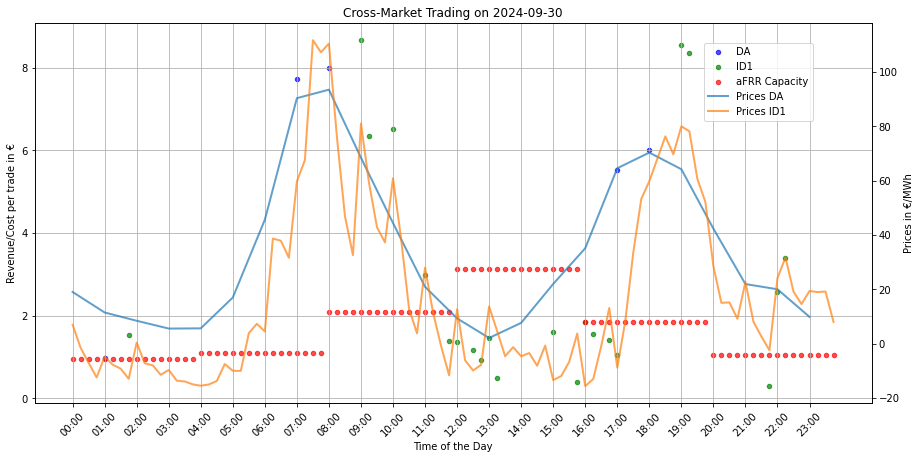

In [20]:
fig, ax1 = plt.subplots(figsize=(15, 7)) 

# replace negative values with 0
results_df_day['DA'] = results_df_day['DA'].apply(lambda x: 0 if x < 0 else x)

# Scatter plot
ax1.scatter(results_df_day.index, results_df_day['DA'].where(results_df_day['DA'] > 0), color='b', alpha=0.7, s=20)
ax1.scatter(results_df_day.index, results_df_day['ID1'].where(results_df_day['ID1'] > 0), color='g', alpha=0.7, s=20)
ax1.scatter(results_df_day.index, results_df_day['aFRR Capacity'].where(results_df_day['aFRR Capacity'] > 0), color='r', alpha=0.7, s=20)
ax1.set_title('Cross-Market Trading on ' + str(results_df_day.index[0].date()))
ax1.set_xlabel('Time of the Day')
ax1.set_ylabel('Revenue/Cost per trade in €')
ax1.grid(True)

# Set x-axis ticks to show hourly intervals
hourly_ticks = results_df_day.index[::4]  
ax1.set_xticks(hourly_ticks)
ax1.set_xticklabels(hourly_ticks.strftime('%H:%M'), rotation=45)  # Format as HH:MM

# Add second y-axis for prices as a line
ax2 = ax1.twinx()
ax2.plot(prices_da.index, prices_da.iloc[:,0], linestyle='-', linewidth=2, alpha=0.7, label='Prices DA')
ax2.plot(prices_id1.index, prices_id1, linestyle='-', linewidth=2, alpha=0.7, label='Prices ID1')
ax2.set_ylabel('Prices in €/MWh')

# Adding legends
fig.legend(['DA', 'ID1', 'aFRR Capacity', 'Prices DA', 'Prices ID1'], loc="upper right", bbox_to_anchor=(0.85, 0.85))

plt.show()


In [19]:
type(prices_id1)

pandas.core.series.Series